# Measure analysis

##### Imports and params

In [1]:
from __future__ import annotations

import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt
import openalea.rsml as rsml

In [2]:
plt.rcParams.update({
"figure.figsize": (18, 10),
"axes.grid": True,
"grid.linestyle": ":",
"grid.alpha": 0.5,
"axes.titlesize": 14,
"axes.labelsize": 12,
"legend.fontsize": 10,
})

In [3]:
MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/Measures/measureresults_per_plant.csv").expanduser()
GT_MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/Ground_truth_root.csv").expanduser()
PATH_2_LOGS = Path("/home/loai/Documents/code/RSMLExtraction/Measures/all_events_combined.csv").expanduser()

## Loading database

In [4]:
df_base = pd.read_csv(MORPHO_RESULTS)
df_base.head()

,model,split,box,metric,time,root_ids,source,value
0,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",Prediction,1.0
1,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",expertized,1.0
2,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",before_expertized,1.0
3,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",Prediction,1.0
4,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",expertized,1.0


In [5]:
    # divide model into three columns, model_name, loss_name and epoch
df_base['model_name'] = df_base['model'].str.split('_').str[0]
pos_number_in_model = df_base['model'].str.split('_').apply(lambda x: next((i for i, part in enumerate(x) if part.isdigit()), -1))


df_base['loss_name'] = df_base.apply(
	lambda row: '_'.join(row['model'].split('_')[1:pos_number_in_model[row.name]])
	if pos_number_in_model[row.name] != -1
	else '_'.join(row['model'].split('_')[1:]),
	axis=1
)

def extract_epoch(row):
	pos = pos_number_in_model[row.name]
	if pos != -1:
		part = row['model'].split('_')[pos]
		return int(part.replace('epoch', '')) if 'epoch' in part else int(part)
	else:
		return -1

df_base['epoch'] = df_base.apply(extract_epoch, axis=1)

# remove _number from loss_name
df_base['loss_name'] = df_base['loss_name'].str.replace(r'_\d+', '', regex=True)
df_base.head()


,model,split,box,metric,time,root_ids,source,value,model_name,loss_name,epoch
0,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",Prediction,1.0,Segformer,bce_dice,-1
1,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",expertized,1.0,Segformer,bce_dice,-1
2,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",before_expertized,1.0,Segformer,bce_dice,-1
3,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",Prediction,1.0,Segformer,bce_dice,-1
4,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",expertized,1.0,Segformer,bce_dice,-1


In [6]:
# get all boxes in the df_base
boxes = df_base['box'].unique()
path_2_rsmls = "/home/loai/Images/DataTest/UC1/UC1_OLD/"
# foe each box, path_2_rsmls + box + "/61_graph_expertized.rsml"
for box in boxes:
    rsml_path = Path(path_2_rsmls) / f"{box}/61_graph_expertized.rsml"
    graph = rsml.rsml2mtg(str(rsml_path))
    metadata = graph.graph_properties().get('metadata', {})
        
    obs_hours = [float(h) for h in metadata.get('observation-hours', "").split(',') if h]
    pixel_size = float(metadata.get('pixel-size', 76.0))
    
    mask = df_base['box'] == box
    df_base.loc[mask, 'pixel_size'] = pixel_size * 1e-3 # convert to mm
    
    def map_time(idx):
        try:
            return obs_hours[int(idx) - 1]
        except (IndexError, ValueError):
            return None
    df_base.loc[mask, 'time_hours'] = df_base.loc[mask, 'time'].apply(map_time)
df_base.head()

,model,split,box,metric,time,root_ids,source,value,model_name,loss_name,epoch,pixel_size,time_hours
0,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",Prediction,1.0,Segformer,bce_dice,-1,0.076,0.0
1,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",expertized,1.0,Segformer,bce_dice,-1,0.076,0.0
2,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(1, 1, 1)",before_expertized,1.0,Segformer,bce_dice,-1,0.076,0.0
3,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",Prediction,1.0,Segformer,bce_dice,-1,0.076,0.0
4,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,"(36, 47, 45)",expertized,1.0,Segformer,bce_dice,-1,0.076,0.0


In [7]:
combination_counts = df_base.groupby(['model_name', 'loss_name']).size().reset_index(name='counts')

combination_counts = combination_counts.groupby(['model_name', 'loss_name']).agg({'counts': 'sum'}).reset_index()
print(combination_counts)

  model_name    loss_name  counts
0  Segformer          bce  269352
1  Segformer     bce_dice  210888
2  Segformer         dice  329208
3       Unet          bce  364002
4       Unet     bce_dice  359100
5       Unet  cldice_dice  327810
6       Unet         dice  359100


In [8]:
df_base = df_base.drop(columns=['model', 'split'])

# order by model_name, loss_name, epoch, box and time
df_base = df_base.sort_values(by=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'pixel_size'])

# pivot on source "source" and value is "value" column 
df_base = df_base.pivot_table(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids', 'metric', 'pixel_size'], columns='source', values='value').reset_index()

# for col not in 'model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids', 'metric', 'pixel_size', multiply by pixel_size
metadata_cols = ['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids', 'metric', 'pixel_size']
for col in df_base.columns:
    if col not in metadata_cols:
        df_base[col] = df_base[col] * df_base['pixel_size']
    
df_base.drop(columns=['pixel_size'], inplace=True)

# remove rows where metric is Intercept_curve_Area
df_base = df_base[df_base['metric'] != 'Intercept_curve_Area']
# remove loss_name = 'bce_dice' 
df_base = df_base[df_base['loss_name'] != 'bce_dice']
        

df_base.head()


source,model_name,loss_name,epoch,box,time,time_hours,root_ids,metric,Prediction,before_expertized,expertized
0,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",Convex_Area_Hull,25.746644,25.798397,25.798397
2,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",LateralRootLength,0.000000,0.000000,0.000000
3,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",NumberOfLateralRoots,0.000000,0.000000,0.000000
4,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",NumberOfOrgans,0.076000,0.076000,0.076000
5,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",PrimaryRootLength,13.275143,13.498684,13.498684


In [9]:
combination_counts = df_base.groupby(['model_name', 'loss_name']).size().reset_index(name='counts')
print(combination_counts)

  model_name    loss_name  counts
0  Segformer          bce   78561
1  Segformer         dice   96019
2       Unet          bce  106167
3       Unet  cldice_dice   95611
4       Unet         dice  104736


In [10]:
# metrcis should be column and not rows, so we need to pivot the table
df_plant = df_base.pivot(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], columns="metric", values="Prediction").reset_index()
df_plant.head()

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,NumberOfOrgans,PrimaryRootLength,RootDensity,TotalRootLength
0,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",25.746644,0.0,0.0,0.076,13.275143,0.039186,13.275143
1,Segformer,bce,-1,230629PN006,1,0.0,"(11, 23, 12)",26.035481,0.0,0.0,0.076,13.307390,0.038846,13.307390
2,Segformer,bce,-1,230629PN006,1,0.0,"(15, 31, 15)",28.241310,0.0,0.0,0.076,14.308127,0.038505,14.308127
3,Segformer,bce,-1,230629PN006,1,0.0,"(4, 9, 5)",31.864120,0.0,0.0,0.076,16.196924,0.038632,16.196924
4,Segformer,bce,-1,230629PN006,1,0.0,"(8, 21, 10)",26.079679,0.0,0.0,0.076,13.355308,0.038919,13.355308


In [11]:
df_plant_gt = df_base.pivot(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], columns="metric", values="expertized").reset_index()
df_plant_bgt = df_base.pivot(index=['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids'], columns="metric", values="before_expertized").reset_index()

df_plant_gt.head()

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,NumberOfOrgans,PrimaryRootLength,RootDensity,TotalRootLength
0,Segformer,bce,-1,230629PN006,1,0.0,"(1, 1, 1)",25.798397,0.0,0.0,0.076,13.498684,0.039766,13.498684
1,Segformer,bce,-1,230629PN006,1,0.0,"(11, 23, 12)",26.071457,0.0,0.0,0.076,13.453554,0.039218,13.453554
2,Segformer,bce,-1,230629PN006,1,0.0,"(15, 31, 15)",28.269034,0.0,0.0,0.076,14.400807,0.038716,14.400807
3,Segformer,bce,-1,230629PN006,1,0.0,"(4, 9, 5)",31.889034,0.0,0.0,0.076,16.337364,0.038936,16.337364
4,Segformer,bce,-1,230629PN006,1,0.0,"(8, 21, 10)",26.323846,0.0,0.0,0.076,13.629917,0.039351,13.629917


In [12]:
def process_plant_kinematics(df):
    metadata_cols = ['model_name', 'loss_name', 'epoch', 'box', 'time', 'time_hours', 'root_ids']
    no_speed_cols = ['NumberOfOrgans', 'NumberOfLateralRoots', 'Intercept_curve_Area']
    metrics = [c for c in df.columns if c not in metadata_cols or c in no_speed_cols]
    
    df = df.sort_values(by=['model_name', 'loss_name', 'epoch', 'box', 'root_ids', 'time_hours'])
    
    grouper = df.groupby(['model_name', 'loss_name', 'epoch', 'box', 'root_ids'])
    
    for metric in metrics:
        speed_col = f"{metric}_speed"
        df[speed_col] = grouper[metric].diff() / grouper['time_hours'].diff()
        
        accel_col = f"{metric}_acceleration"
        df[accel_col] = grouper[speed_col].diff() / grouper['time_hours'].diff()
        
    return df

# Apply to your three dataframes
df_plant = process_plant_kinematics(df_plant)
df_plant_gt = process_plant_kinematics(df_plant_gt)
df_plant_bgt = process_plant_kinematics(df_plant_bgt)

# Preview results for one metric (e.g., 'length')
df_plant

metric,model_name,loss_name,epoch,box,time,time_hours,root_ids,Convex_Area_Hull,LateralRootLength,NumberOfLateralRoots,...,NumberOfLateralRoots_speed,NumberOfLateralRoots_acceleration,NumberOfOrgans_speed,NumberOfOrgans_acceleration,PrimaryRootLength_speed,PrimaryRootLength_acceleration,RootDensity_speed,RootDensity_acceleration,TotalRootLength_speed,TotalRootLength_acceleration
0,Segformer,bce,-1,230629PN006,1,0.0000,"(1, 1, 1)",25.746644,0.000000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Segformer,bce,-1,230629PN006,2,13.6588,"(1, 1, 1)",31.325157,0.000000,0.000,...,0.000000,NaN,0.000000,NaN,0.205950,NaN,-0.000011,NaN,0.205950,NaN
10,Segformer,bce,-1,230629PN006,3,19.6578,"(1, 1, 1)",34.053921,0.000000,0.000,...,0.000000,0.000000,0.000000,0.000000,0.230819,0.004146,-0.000006,8.340723e-07,0.230819,0.004146
15,Segformer,bce,-1,230629PN006,4,25.6585,"(1, 1, 1)",36.486474,0.000000,0.000,...,0.000000,0.000000,0.000000,0.000000,0.204220,-0.004433,-0.000008,-2.713931e-07,0.204220,-0.004433
20,Segformer,bce,-1,230629PN006,5,31.6574,"(1, 1, 1)",38.161103,0.000000,0.000,...,0.000000,0.000000,0.000000,0.000000,0.139934,-0.010716,-0.000006,2.735802e-07,0.139934,-0.010716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68709,Unet,dice,260,230629PN031,25,159.2198,"(45, 84, 81)",62.081760,99.219833,0.836,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004412,1.654057e-03,4.318422,1.645602
68714,Unet,dice,260,230629PN031,26,164.6053,"(45, 84, 81)",63.699601,110.010033,0.836,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001655,-5.119457e-04,2.003565,-0.429831
68719,Unet,dice,260,230629PN031,27,170.5999,"(45, 84, 81)",65.958104,117.247235,0.912,...,0.012678,0.002115,0.012678,0.002115,0.000000,0.000000,0.000449,-2.011168e-04,1.207287,-0.132833
68724,Unet,dice,260,230629PN031,28,181.3910,"(45, 84, 81)",68.153004,124.497969,0.988,...,0.007043,-0.000522,0.007043,-0.000522,0.000000,0.000000,0.000249,-1.854752e-05,0.671918,-0.049612


### Logs

In [13]:
cols_to_keep = ['step', 'value', 'folder', 'metric']
df_logs_tb = pd.read_csv(PATH_2_LOGS, usecols=lambda c: c in cols_to_keep)

# create new columns for model name and loss name
df_logs_tb['model_name'] = df_logs_tb['folder'].str.split('/').str[9].str.split('_').str[0]
df_logs_tb['loss_name'] = df_logs_tb['folder'].str.split('/').str[9].str.split('_').str[1:].str.join('_')

df_logs_tb = df_logs_tb.rename(columns={"step": "epoch", "value": "model_metric_value"})

df_logs_tb = df_logs_tb[df_logs_tb['metric'] != 'batch_loss']
# drop learning rate
df_logs_tb = df_logs_tb[df_logs_tb['metric'] != 'learning_rate']

df_logs_tb = df_logs_tb.drop(columns=['folder'])

print("Available loss names:", df_logs_tb['loss_name'].unique().tolist())
df_logs_tb.head()


Available loss names: ['cldice', 'bce_dice', 'bce', 'cldice_dice', 'dice']


,metric,model_metric_value,epoch,model_name,loss_name
0,train/batch_loss,0.925660,0,Segformer,cldice
1,train/batch_loss,0.516224,1,Segformer,cldice
2,train/batch_loss,0.452731,2,Segformer,cldice
3,train/batch_loss,0.401067,3,Segformer,cldice
4,train/batch_loss,0.288061,4,Segformer,cldice


In [14]:
# all model_name, loss_name and metric + model_metric_value at last epoch
df_logs_tb_last_epoch = df_logs_tb.groupby(['model_name', 'loss_name', 'metric']).last().reset_index()
df_logs_tb_last_epoch

,model_name,loss_name,metric,model_metric_value,epoch
0,Segformer,bce,train/batch_loss,6.780987e-03,3730
1,Segformer,bce,train/epoch_loss,5.593757e-03,287
2,Segformer,bce,train/lr,1.214915e-08,287
3,Segformer,bce,val/APLS,8.555117e-01,286
4,Segformer,bce,val/AverageCenterlineDistance,6.817138e-01,286
...,...,...,...,...,...
305,Unet,dice,val/Precision,9.360902e-01,261
306,Unet,dice,val/Recall,9.585271e-01,261
307,Unet,dice,val/Specificity,9.992206e-01,261
308,Unet,dice,val/VI,0.000000e+00,261


## Prepare diff datasets

In [15]:
# all columns that are not model_name, loss_name, epoch, box and time are metrics
metric_columns = [col for col in df_plant.columns if col not in ['model_name', 'loss_name', 'epoch', "box", "time", "root_ids"]]
df_diff = df_plant_gt.copy()

for metric in metric_columns:
    df_diff[f"{metric}_signed_err"] = df_plant[metric] - df_plant_gt[metric]
    
    df_diff[f"{metric}_abs_err"] = df_diff[f"{metric}_signed_err"].abs()
    
    floatgt = abs(df_plant_gt[metric].astype(float).replace(0, pd.NA)) # 
    df_diff[f'{metric}_rel_err'] = df_diff[f"{metric}_abs_err"] / (floatgt + 1e-9)
    
# drop TimeStep_signed_err, TimeStep_abs_err and TimeStep_rel_err if they exist
df_diff = df_diff.drop(columns=metric_columns)

#df_diff.dropna(inplace=True)

print("Available loss names:", df_diff['loss_name'].unique().tolist())

df_diff.head()

Available loss names: ['bce', 'dice', 'cldice_dice']


metric,model_name,loss_name,epoch,box,time,root_ids,time_hours_signed_err,time_hours_abs_err,time_hours_rel_err,Convex_Area_Hull_signed_err,...,RootDensity_speed_rel_err,RootDensity_acceleration_signed_err,RootDensity_acceleration_abs_err,RootDensity_acceleration_rel_err,TotalRootLength_speed_signed_err,TotalRootLength_speed_abs_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_signed_err,TotalRootLength_acceleration_abs_err,TotalRootLength_acceleration_rel_err
0,Segformer,bce,-1,230629PN006,1,"(1, 1, 1)",0.0,0.0,<NA>,-0.051754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Segformer,bce,-1,230629PN006,2,"(1, 1, 1)",0.0,0.0,0.0,0.104309,...,0.323507,NaN,NaN,NaN,0.005055,0.005055,0.025164,NaN,NaN,NaN
10,Segformer,bce,-1,230629PN006,3,"(1, 1, 1)",0.0,0.0,0.0,0.104843,...,0.601063,6.708699e-07,6.708699e-07,4.085628,0.001206,0.001206,0.005252,-0.000642,0.000642,0.134036
15,Segformer,bce,-1,230629PN006,4,"(1, 1, 1)",0.0,0.0,0.0,0.106524,...,0.477929,-3.663248e-07,3.663248e-07,3.818602,0.001182,0.001182,0.005820,-0.000004,0.000004,0.000914
20,Segformer,bce,-1,230629PN006,5,"(1, 1, 1)",0.0,0.0,0.0,-0.193428,...,1.113058,-1.141713e-05,1.141713e-05,0.976515,-0.058300,0.058300,0.294097,-0.009915,0.009915,12.379335


## Merge with logs

In [16]:
subset_keys = ['epoch', 'loss_name', 'model_name', 'metric']

# remove metric = train/batch_loss
df_logs_tb = df_logs_tb[~df_logs_tb['metric'].isin(['train/batch_loss', 'train/lr'])]

# metric named : val/val_loss_BCE, val/val_loss_BCEDiceLoss, val/val_loss_CLDice, val/val_loss_CLDice_Dice and val/val_loss_DiceLoss
# Combine all these columns into one column named val/val_loss, and drop the original columns

for vallos in ['val/val_loss_BCE', 'val/val_loss_BCEDiceLoss', 'val/val_loss_CLDice', 'val/val_loss_CLDice_Dice', 'val/val_loss_DiceLoss']:
    if vallos in df_logs_tb['metric'].unique():
        df_logs_tb.loc[df_logs_tb['metric'] == vallos, 'metric'] = 'val/val_loss'
    else:
        print(f"Metric {vallos} not found in logs. Setting val/val_loss to N/A for this metric.")

In [17]:
duplicates_mask = df_logs_tb.duplicated(subset=subset_keys, keep=False)
df_duplicates = df_logs_tb[duplicates_mask]

df_duplicates = df_duplicates.sort_values(by=subset_keys)

print(f"Nombre total de lignes dupliquées : {len(df_duplicates)}")
print("Aperçu des doublons :")
df_duplicates

Nombre total de lignes dupliquées : 0
Aperçu des doublons :


,metric,model_metric_value,epoch,model_name,loss_name


In [18]:
last_epochs = df_logs_tb.groupby(['model_name', 'loss_name'])['epoch'].max().reset_index()
last_epoch_dict = {(row['model_name'], row['loss_name']): row['epoch'] for _, row in last_epochs.iterrows()}

print(last_epoch_dict)

{('Segformer', 'bce'): 287, ('Segformer', 'bce_dice'): 286, ('Segformer', 'cldice'): 288, ('Segformer', 'cldice_dice'): 291, ('Segformer', 'dice'): 300, ('Unet', 'bce'): 264, ('Unet', 'bce_dice'): 268, ('Unet', 'cldice'): 266, ('Unet', 'cldice_dice'): 261, ('Unet', 'dice'): 262}


In [19]:
def replace_epoch(row):
    if row['epoch'] == -1:
        return last_epoch_dict.get((row['model_name'], row['loss_name']), -1)
    
    return row['epoch']

df_diff['epoch'] = df_diff.apply(replace_epoch, axis=1)
df_diff.head()


metric,model_name,loss_name,epoch,box,time,root_ids,time_hours_signed_err,time_hours_abs_err,time_hours_rel_err,Convex_Area_Hull_signed_err,...,RootDensity_speed_rel_err,RootDensity_acceleration_signed_err,RootDensity_acceleration_abs_err,RootDensity_acceleration_rel_err,TotalRootLength_speed_signed_err,TotalRootLength_speed_abs_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_signed_err,TotalRootLength_acceleration_abs_err,TotalRootLength_acceleration_rel_err
0,Segformer,bce,287,230629PN006,1,"(1, 1, 1)",0.0,0.0,<NA>,-0.051754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Segformer,bce,287,230629PN006,2,"(1, 1, 1)",0.0,0.0,0.0,0.104309,...,0.323507,NaN,NaN,NaN,0.005055,0.005055,0.025164,NaN,NaN,NaN
10,Segformer,bce,287,230629PN006,3,"(1, 1, 1)",0.0,0.0,0.0,0.104843,...,0.601063,6.708699e-07,6.708699e-07,4.085628,0.001206,0.001206,0.005252,-0.000642,0.000642,0.134036
15,Segformer,bce,287,230629PN006,4,"(1, 1, 1)",0.0,0.0,0.0,0.106524,...,0.477929,-3.663248e-07,3.663248e-07,3.818602,0.001182,0.001182,0.005820,-0.000004,0.000004,0.000914
20,Segformer,bce,287,230629PN006,5,"(1, 1, 1)",0.0,0.0,0.0,-0.193428,...,1.113058,-1.141713e-05,1.141713e-05,0.976515,-0.058300,0.058300,0.294097,-0.009915,0.009915,12.379335


In [20]:
df_logs_pivoted = df_logs_tb.pivot_table(
    index=['epoch', 'loss_name', 'model_name'], 
    columns='metric', 
    values='model_metric_value',
    aggfunc='first'  
).reset_index()

# val/val_loss_BCE, val/val_loss_CLDice_Dice and val/val_loss_DiceLoss should have missing values -> combine them into one column val/val_loss
#df_logs_pivoted['val/val_loss'] = df_logs_pivoted[['val/val_loss_BCE', 'val/val_loss_CLDice_Dice', 'val/val_loss_DiceLoss']].bfill(axis=1).iloc[:, 0]
#df_logs_pivoted = df_logs_pivoted.drop(columns=['val/val_loss_BCE', 'val/val_loss_CLDice_Dice', 'val/val_loss_DiceLoss'])

print("Available loss names:", df_logs_pivoted['loss_name'].unique().tolist())

df_logs_pivoted

Available loss names: ['bce', 'bce_dice', 'cldice', 'cldice_dice', 'dice']


metric,epoch,loss_name,model_name,train/epoch_loss,val/APLS,val/AverageCenterlineDistance,val/Betti0JaccardRatioGPU,val/Betti0RelativeErrorGPU,val/Betti0VariationIndexGPU,val/Betti1JaccardRatioGPU,...,val/PersistenceBottleneckGPUParallel_1,val/PersistenceWassersteinGPUParallel,val/PersistenceWassersteinGPUParallel_0,val/PersistenceWassersteinGPUParallel_1,val/PixelAccuracy,val/Precision,val/Recall,val/Specificity,val/VI,val/val_loss
0,1,bce,Segformer,0.337148,0.000000,33167.902344,0.000000,1.000000,1.000000,0.000000,...,0.404297,0.0,6.626992,362.356567,0.988176,0.000000,0.000000,1.000000,0.0,1.182380
1,1,bce,Unet,0.133981,0.000000,33167.902344,0.000000,1.000000,1.000000,0.000000,...,0.404297,0.0,6.626992,362.356567,0.988176,0.000000,0.000000,1.000000,0.0,1.182380
2,1,bce_dice,Segformer,1.649649,0.000713,4.224051,0.075866,14.433867,0.860277,0.000000,...,0.500000,0.0,6.626992,420.348816,0.990544,0.927636,0.215306,0.999808,0.0,1.323413
3,1,bce_dice,Unet,1.522699,0.000000,33167.902344,0.000000,1.000000,1.000000,0.000000,...,0.404297,0.0,6.626992,362.356567,0.988176,0.000000,0.000000,1.000000,0.0,1.693147
4,1,cldice,Segformer,0.318807,0.805931,1.197869,0.731896,0.268104,0.165130,0.451609,...,0.396484,0.0,16.507212,579.819458,0.985413,0.445631,0.999988,0.985236,0.0,0.035351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,296,dice,Segformer,0.209388,0.877581,0.700057,0.707586,0.475550,0.184611,0.525358,...,0.416016,0.0,3.442202,126.035126,0.997991,0.893427,0.941704,0.998666,0.0,0.085159
2769,297,dice,Segformer,0.212590,0.882606,0.700767,0.703374,0.469406,0.187176,0.526727,...,0.416016,0.0,3.470937,135.797913,0.997984,0.890409,0.944962,0.998620,0.0,0.085332
2770,298,dice,Segformer,0.209163,0.882928,0.700514,0.705546,0.469069,0.185603,0.527270,...,0.414062,0.0,3.471411,134.321457,0.997985,0.890842,0.944471,0.998626,0.0,0.085316
2771,299,dice,Segformer,0.214958,0.878187,0.700855,0.706664,0.473536,0.185487,0.525633,...,0.417969,0.0,3.455051,127.977791,0.997988,0.892582,0.942481,0.998654,0.0,0.085268


In [21]:
df_diff_log = pd.merge(
    df_diff,
    df_logs_pivoted, 
    on=['epoch', 'loss_name', 'model_name'],
    how='left'
)

#df_diff_log = df_diff_log.dropna()

# print number of lines for every model_name x loss_name combination
combination_counts = df_diff_log.groupby(['model_name', 'loss_name']).size().reset_index(name='counts')
print(combination_counts)


df_diff_log.head()

  model_name    loss_name  counts
0  Segformer          bce   11223
1  Segformer         dice   13717
2       Unet          bce   15167
3       Unet  cldice_dice   13659
4       Unet         dice   14964


metric,model_name,loss_name,epoch,box,time,root_ids,time_hours_signed_err,time_hours_abs_err,time_hours_rel_err,Convex_Area_Hull_signed_err,...,val/PersistenceBottleneckGPUParallel_1,val/PersistenceWassersteinGPUParallel,val/PersistenceWassersteinGPUParallel_0,val/PersistenceWassersteinGPUParallel_1,val/PixelAccuracy,val/Precision,val/Recall,val/Specificity,val/VI,val/val_loss
0,Segformer,bce,287,230629PN006,1,"(1, 1, 1)",0.0,0.0,<NA>,-0.051754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Segformer,bce,287,230629PN006,2,"(1, 1, 1)",0.0,0.0,0.0,0.104309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Segformer,bce,287,230629PN006,3,"(1, 1, 1)",0.0,0.0,0.0,0.104843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Segformer,bce,287,230629PN006,4,"(1, 1, 1)",0.0,0.0,0.0,0.106524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Segformer,bce,287,230629PN006,5,"(1, 1, 1)",0.0,0.0,0.0,-0.193428,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visualize raw data

### Utils

In [22]:
import ipywidgets as widgets
from IPython.display import display

In [23]:
# List all loss names, model names, and metrics
loss_names = df_diff_log['loss_name'].unique().tolist()
model_names = df_diff_log['model_name'].unique().tolist()
col_box_name = df_diff_log["box"].unique().tolist()
col_plant_number = df_diff_log["root_ids"].unique().tolist()
col_time_hours = df_diff_log['time'].unique().tolist()
col_time_hours.sort()
col_epoch = df_diff_log["epoch"].unique().tolist()
col_epoch.sort()
img_metrics = df_logs_tb['metric'].unique().tolist()
plant_errors = df_diff_log.columns.tolist()
# remove everything that is not a measure
for col in ['epoch', 'loss_name', 'model_name', 'box',  'root_ids', 'TimeStep', 'FileName', 'time', 'Acquisition Time'] + img_metrics:
    if col in plant_errors:
        plant_errors.remove(col)
print("Available loss names:", loss_names)
print("Available model names:", model_names)
print("Available box names:", col_box_name)
print("Available plant numbers:", col_plant_number)
print("Available epochs:", col_epoch)
print("Available image metrics:", img_metrics)
print("Available plant errors:", plant_errors)


Available loss names: ['bce', 'dice', 'cldice_dice']
Available model names: ['Segformer', 'Unet']
Available box names: ['230629PN006', '230629PN008', '230629PN010', '230629PN012', '230629PN014', '230629PN018', '230629PN019', '230629PN024', '230629PN027', '230629PN031']
Available plant numbers: ['(1, 1, 1)', '(11, 23, 12)', '(15, 31, 15)', '(4, 9, 5)', '(8, 21, 10)', '(16, 11, 8)', '(8, 1, 1)', '(15, 1, 3)', '(26, 16, 14)', '(44, 35, 32)', '(56, 50, 48)', '(19, 22, 20)', '(40, 45, 41)', '(58, 65, 60)', '(76, 85, 80)', '(15, 15, 14)', '(29, 34, 32)', '(44, 50, 48)', '(61, 69, 66)', '(16, 23, 13)', '(4, 7, 4)', '(8, 14, 8)', '(24, 19, 5)', '(40, 36, 22)', '(57, 52, 37)', '(72, 70, 54)', '(16, 1, 1)', '(34, 27, 25)', '(51, 46, 46)', '(67, 65, 65)', '(13, 16, 9)', '(19, 22, 15)', '(6, 10, 6)', '(17, 19, 18)', '(43, 47, 45)', '(58, 66, 63)', '(75, 84, 81)', '(10, 21, 10)', '(13, 23, 12)', '(18, 31, 15)', '(6, 9, 5)', '(14, 11, 8)', '(23, 1, 3)', '(36, 16, 14)', '(52, 35, 32)', '(64, 50, 48)'

### Visu

In [24]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# --- 1. Define Widgets ---

w_model = widgets.Dropdown(
    options=sorted(df_diff_log['model_name'].unique()), 
    description='Model:'
)

w_loss = widgets.Dropdown(
    options=sorted(df_diff_log['loss_name'].unique()), 
    description='Loss:'
)

w_box = widgets.Dropdown(
    options=sorted(df_diff_log['box'].unique()), 
    description='Box:'
)

# Initialize with a placeholder to prevent "nonempty" error on startup
w_epoch = widgets.SelectionSlider(
    options=['N/A'], 
    description='Epoch:',
    continuous_update=False,
    disabled=True 
)

w_root_id = widgets.Dropdown(
    options=[], 
    description='Root ID:'
)

w_measure = widgets.Dropdown(
    options=plant_errors, 
    description='Measure:'
)

def update_dependent_options(*_):
    curr_model = w_model.value
    curr_loss = w_loss.value
    curr_box = w_box.value
    
    # Filter data
    subset = df_diff_log[
        (df_diff_log['model_name'] == curr_model) & 
        (df_diff_log['loss_name'] == curr_loss) & 
        (df_diff_log['box'] == curr_box)
    ]
    
    # --- Update Epochs (Fix for TraitError) ---
    available_epochs = sorted(subset['epoch'].unique())
    
    if len(available_epochs) > 0:
        w_epoch.options = available_epochs
        w_epoch.disabled = False
        # Preserve selection if valid
        if w_epoch.value not in available_epochs:
            w_epoch.value = available_epochs[-1]
    else:
        # Fallback if no data: set a dummy option
        w_epoch.options = ['N/A'] 
        w_epoch.disabled = True

    available_roots = sorted(subset['root_ids'].unique())
    
    if len(available_roots) > 0:
        w_root_id.options = available_roots
        w_root_id.disabled = False
        if w_root_id.value not in available_roots:
            w_root_id.value = available_roots[0]
    else:
        w_root_id.options = ['N/A']
        w_root_id.disabled = True

w_model.observe(update_dependent_options, names='value')
w_loss.observe(update_dependent_options, names='value')
w_box.observe(update_dependent_options, names='value')

update_dependent_options()

def plot_logic(model_name, loss_name, epoch, box, root_id, measure):
    if epoch == 'N/A' or root_id == 'N/A':
        plt.figure(figsize=(14, 6))
        plt.text(0.5, 0.5, "No data available for this selection", 
                 ha='center', va='center', fontsize=14)
        plt.tight_layout()
        plt.show()
        return

    df_filtered = df_diff_log[
        (df_diff_log['model_name'] == model_name) &
        (df_diff_log['loss_name'] == loss_name) &
        (df_diff_log['epoch'] == epoch) &
        (df_diff_log['box'] == box) &
        (df_diff_log['root_ids'] == root_id)
    ]
    
    df_filtered = df_filtered.sort_values('time').copy()
    # remove rows where measure is NaN
    df_filtered = df_filtered[~df_filtered[measure].isna()]

    plt.figure(figsize=(14, 6))
    
    if df_filtered.empty:
        plt.text(0.5, 0.5, "No data found", ha='center', va='center', fontsize=14)
    else:
        plt.plot(df_filtered['time'], df_filtered[measure], 
                 marker='o', color='teal', label=measure, 
                 linewidth=2, markersize=4, alpha=0.8)
        
        plt.title(f'Analysis: {measure}\n({model_name} | {loss_name} | Epoch {epoch} | Box {box} | Root {root_id})')
        plt.xlabel('Time (hours)')
        plt.ylabel(measure)
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

ui = widgets.VBox([
    widgets.HBox([w_model, w_loss, w_epoch]),
    widgets.HBox([w_box, w_root_id]),
    widgets.HBox([w_measure])
])

out = widgets.interactive_output(plot_logic, {
    'model_name': w_model,
    'loss_name': w_loss,
    'epoch': w_epoch,
    'box': w_box,
    'root_id': w_root_id,
    'measure': w_measure
})

display(ui, out)

Output()

## Per epoch visualization

In [25]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'rel_err' in m ]

# Remplacer -1 par l'epoch max pour chaque combinaison model_name x loss_name
last_epochs = df_diff_log.groupby(['model_name', 'loss_name'])['epoch'].max().reset_index()
last_epoch_dict = {(row['model_name'], row['loss_name']): row['epoch'] for _, row in last_epochs.iterrows()}
df_diff_log['epoch'] = df_diff_log.apply(lambda row: last_epoch_dict.get((row['model_name'], row['loss_name']), row['epoch']) if row['epoch'] == -1 else row['epoch'], axis=1)

df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log.groupby(['model_name', 'loss_name'])['epoch'].transform('max')].groupby(['model_name', 'loss_name'])[target_metrics].mean()
best_configs = []

for metric in target_metrics:
    min_val = df_grouped[metric].min()
    winners = df_grouped[df_grouped[metric] <= min_val + 1e-4]
    for (model, loss), row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
            'Best Model': model,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

display(df_best.style.background_gradient(subset=['Min Mean Error'], cmap='Greens_r'))

/tmp/ipykernel_239387/1538262344.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/1538262344.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/1538262344.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/1538262344.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/1538262344.py:20: UserWarning: Boolean Series key will be reindexed to match D

,Metric,epoch,Best Model,Best Loss,Min Mean Error
0,time_hours_rel_err,287,Segformer,bce,0.000000
1,time_hours_rel_err,300,Segformer,dice,0.000000
2,time_hours_rel_err,264,Unet,bce,0.000000
3,time_hours_rel_err,261,Unet,cldice_dice,0.000000
4,time_hours_rel_err,262,Unet,dice,0.000000
5,Convex_Area_Hull_rel_err,262,Unet,dice,0.019543
6,LateralRootLength_rel_err,262,Unet,dice,0.467411
7,NumberOfLateralRoots_rel_err,264,Unet,bce,0.297213
8,NumberOfOrgans_rel_err,264,Unet,bce,0.195940
9,PrimaryRootLength_rel_err,287,Segformer,bce,0.016499


In [26]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'rel_err' in m ]

last_epochs = df_diff_log.groupby(['model_name', 'loss_name'])['epoch'].max().reset_index()
last_epoch_dict = {(row['model_name'], row['loss_name']): row['epoch'] for _, row in last_epochs.iterrows()}
df_diff_log['epoch'] = df_diff_log.apply(lambda row: last_epoch_dict.get((row['model_name'], row['loss_name']), row['epoch']) if row['epoch'] == -1 else row['epoch'], axis=1)

df_grouped = df_diff_log[df_diff_log['epoch'] == df_diff_log.groupby(['model_name', 'loss_name'])['epoch'].transform('max')].groupby(['model_name', 'loss_name'])[target_metrics].mean() # meean over all measures for each model_name x loss_name combination at last epoch
best_configs = []

for metric in target_metrics:
    max_val = df_grouped[metric].max()
    winners = df_grouped[df_grouped[metric] >= max_val - 1e-4]
    for (model, loss), row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
            'Best Model': model,
            'Best Loss': loss,
            'Max Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

display(df_best.style.background_gradient(subset=['Max Mean Error'], cmap='Reds_r'))

/tmp/ipykernel_239387/247096758.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/247096758.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/247096758.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/247096758.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'epoch': df_diff_log[df_diff_log['model_name'] == model][df_diff_log['loss_name'] == loss]['epoch'].max(),
/tmp/ipykernel_239387/247096758.py:19: UserWarning: Boolean Series key will be reindexed to match DataFr

,Metric,epoch,Best Model,Best Loss,Max Mean Error
0,time_hours_rel_err,287,Segformer,bce,0.000000
1,time_hours_rel_err,300,Segformer,dice,0.000000
2,time_hours_rel_err,264,Unet,bce,0.000000
3,time_hours_rel_err,261,Unet,cldice_dice,0.000000
4,time_hours_rel_err,262,Unet,dice,0.000000
5,Convex_Area_Hull_rel_err,264,Unet,bce,0.020489
6,Convex_Area_Hull_rel_err,261,Unet,cldice_dice,0.020427
7,LateralRootLength_rel_err,287,Segformer,bce,0.552113
8,NumberOfLateralRoots_rel_err,300,Segformer,dice,0.347819
9,NumberOfOrgans_rel_err,300,Segformer,dice,0.229336


## Correlation tables

In [27]:
from scipy.stats import spearmanr, pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plant_errors = ['NumberOfOrgans_signed_err', 'NumberOfOrgans_abs_err', 'NumberOfOrgans_rel_err', 'TotalRootLength_signed_err', 'TotalRootLength_abs_err', 'TotalRootLength_rel_err', 'TotalRootLength_speed_signed_err', 'TotalRootLength_speed_rel_err', 'TotalRootLength_acceleration_signed_err', 'TotalRootLength_acceleration_rel_err', "TotalRootLength_speed_abs_err", "TotalRootLength_acceleration_abs_err"] # 'Convex_Area_Hull_signed_err', 'Convex_Area_Hull_abs_err', 'Convex_Area_Hull_rel_err', 'RootDensity_signed_err', 'RootDensity_abs_err', 'RootDensity_rel_err'

loss_metrics = ['train/epoch_loss', 'val/Dice', 'val/CLDice','val/FocalLoss', 'val/val_loss']
img_metrics =  ['val/Precision', 'val/Recall', 'val/F1Score', 'val/MeanIoU', 'val/HausdorffDistance', 'val/AverageCenterlineDistance', 'val/CenterlineF1'] #, 'val/Betti0JaccardRatioGPU', 'val/Betti0RelativeErrorGPU', 'val/Betti0VariationIndexGPU', 'val/Betti1JaccardRatioGPU', 'val/Betti1RelativeErrorGPU', 'val/Betti1VariationIndexGPU']

scores_img_metrics = ['val/F1Score', 'val/MeanIoU', 'val/Precision', 'val/Recall', 'val/CenterlineF1']

plant_abs_err =  [col for col in plant_errors if 'abs_err' in col]
plant_rel_err = [col for col in plant_errors if 'rel_err' in col]
plant_signed_err = [col for col in plant_errors if 'signed_err' in col]

In [28]:
# mean value over all epochs 
df_diff_log_epoch_mean = df_diff_log.copy()
df_diff_log_epoch_mean.drop(columns=['root_ids', 'box', 'time'], inplace=True)
df_diff_log_epoch_mean = df_diff_log_epoch_mean.groupby(['model_name', 'loss_name', 'epoch']).mean().reset_index() # does not average segmentation metrics because for 1 model x loss x epoch = 1 segmentation value but multiple plants values
df_diff_log_epoch_mean

metric,model_name,loss_name,epoch,time_hours_signed_err,time_hours_abs_err,time_hours_rel_err,Convex_Area_Hull_signed_err,Convex_Area_Hull_abs_err,Convex_Area_Hull_rel_err,LateralRootLength_signed_err,...,val/PersistenceBottleneckGPUParallel_1,val/PersistenceWassersteinGPUParallel,val/PersistenceWassersteinGPUParallel_0,val/PersistenceWassersteinGPUParallel_1,val/PixelAccuracy,val/Precision,val/Recall,val/Specificity,val/VI,val/val_loss
0,Segformer,bce,60,0.0,0.0,0.0,0.196508,1.689868,0.023051,-4.863686,...,0.454044,0.0,2.457374,80.725349,0.997686,0.924447,0.876327,0.999148,0.0,0.231415
1,Segformer,bce,80,0.0,0.0,0.0,0.138018,1.525353,0.020186,-3.737304,...,0.410041,0.0,3.181388,71.780975,0.998024,0.907892,0.926492,0.998884,0.0,0.197610
2,Segformer,bce,160,0.0,0.0,0.0,0.121271,1.539006,0.020289,-3.795942,...,0.413948,0.0,3.249713,71.909470,0.998044,0.909649,0.926344,0.998907,0.0,0.195569
3,Segformer,bce,180,0.0,0.0,0.0,0.126112,1.523819,0.020109,-3.822216,...,0.428653,0.0,3.221135,70.538498,0.998043,0.910666,0.924996,0.998923,0.0,0.195670
4,Segformer,bce,200,0.0,0.0,0.0,0.133131,1.520546,0.020097,-3.722272,...,0.398323,0.0,3.287758,72.039520,0.998047,0.909205,0.927155,0.998901,0.0,0.195298
5,Segformer,bce,220,0.0,0.0,0.0,0.106901,1.547499,0.020391,-4.048741,...,0.411994,0.0,3.177441,69.868950,0.998040,0.910657,0.924764,0.998922,0.0,0.195965
6,Segformer,bce,240,0.0,0.0,0.0,0.141938,1.514152,0.020076,-3.778462,...,0.430607,0.0,3.216611,71.113998,0.998044,0.910230,0.925618,0.998916,0.0,0.195585
7,Segformer,bce,260,0.0,0.0,0.0,0.139088,1.523044,0.020148,-3.860808,...,0.413948,0.0,3.245793,74.103462,0.998047,0.908361,0.928129,0.998888,0.0,0.195306
8,Segformer,bce,287,0.0,0.0,0.0,0.128279,1.520956,0.020104,-3.602509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Segformer,dice,60,0.0,0.0,0.0,0.377584,1.614032,0.022511,-4.547498,...,0.411075,0.0,3.409039,136.765701,0.997857,0.887016,0.937151,0.998583,0.0,0.090458


Corrélation (ρ Spearman):


,NumberOfOrgans_rel_err,TotalRootLength_rel_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_rel_err
val/Precision,0.299,0.282,0.340,0.643
val/Recall,0.215,0.183,0.165,0.420
val/F1Score,0.390,0.292,0.327,0.576
val/MeanIoU,0.500,0.453,0.466,0.543
val/HausdorffDistance,0.616,0.624,0.591,0.299
val/AverageCenterlineDistance,0.557,0.491,0.515,0.495
val/CenterlineF1,0.627,0.617,0.570,0.331


p-values:


/tmp/ipykernel_239387/3535076489.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,NumberOfOrgans_rel_err,TotalRootLength_rel_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_rel_err
val/Precision,0.029,0.040,0.013,0.000
val/Recall,0.122,0.189,0.237,0.002
val/F1Score,0.004,0.034,0.017,0.000
val/MeanIoU,0.000,0.001,0.000,0.000
val/HausdorffDistance,0.000,0.000,0.000,0.030
val/AverageCenterlineDistance,0.000,0.000,0.000,0.000
val/CenterlineF1,0.000,0.000,0.000,0.016


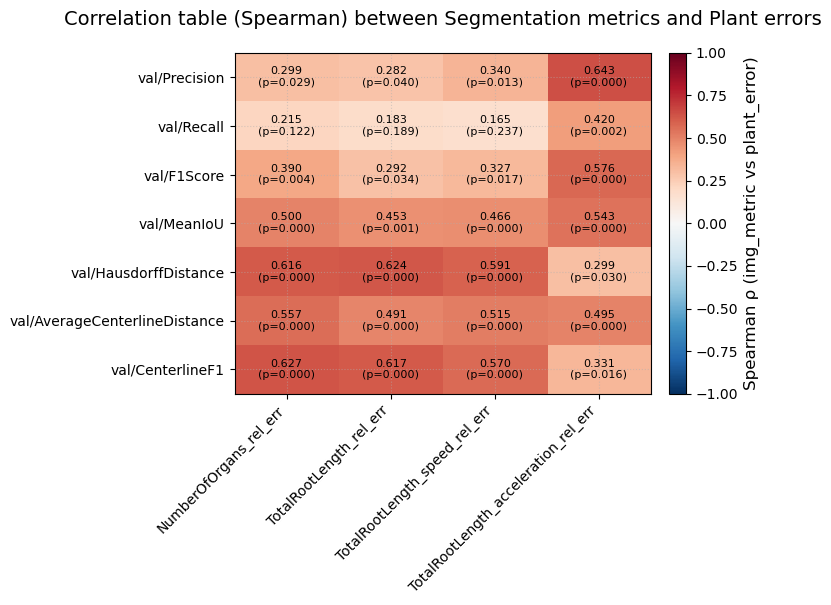

In [34]:
import numpy as np
from scipy.stats import spearmanr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_rel_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].dropna().copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            if img_met in scores_img_metrics:
                valid[img_met] = - valid[img_met]
            rho, p = spearmanr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_rel_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), img_metrics)
plt.xticks(range(len(plant_rel_err)), plant_rel_err, rotation=45, ha="right")
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_rel_err)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")

In [35]:
print("Corrélation (ρ Spearman):")
print(CorrSpearman.round(3))

Corrélation (ρ Spearman):
                               NumberOfOrgans_rel_err  \
val/Precision                                   0.299   
val/Recall                                      0.215   
val/F1Score                                     0.390   
val/MeanIoU                                     0.500   
val/HausdorffDistance                           0.616   
val/AverageCenterlineDistance                   0.557   
val/CenterlineF1                                0.627   

                               TotalRootLength_rel_err  \
val/Precision                                    0.282   
val/Recall                                       0.183   
val/F1Score                                      0.292   
val/MeanIoU                                      0.453   
val/HausdorffDistance                            0.624   
val/AverageCenterlineDistance                    0.491   
val/CenterlineF1                                 0.617   

                               TotalRootLength_speed

Corrélation (ρ Pearson):


,NumberOfOrgans_abs_err,TotalRootLength_abs_err,TotalRootLength_speed_abs_err,TotalRootLength_acceleration_abs_err
val/Precision,-0.119,-0.098,-0.236,-0.104
val/Recall,0.098,-0.107,-0.046,0.074
val/F1Score,0.031,-0.130,-0.158,0.005
val/MeanIoU,0.041,-0.100,-0.157,-0.008
val/HausdorffDistance,0.454,0.536,0.259,0.158
val/AverageCenterlineDistance,0.190,0.173,-0.043,-0.008
val/CenterlineF1,0.419,0.501,0.211,0.056


p-values:


/tmp/ipykernel_239387/405525952.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,NumberOfOrgans_abs_err,TotalRootLength_abs_err,TotalRootLength_speed_abs_err,TotalRootLength_acceleration_abs_err
val/Precision,0.395,0.486,0.089,0.460
val/Recall,0.485,0.445,0.746,0.600
val/F1Score,0.824,0.352,0.257,0.970
val/MeanIoU,0.771,0.474,0.263,0.957
val/HausdorffDistance,0.001,0.000,0.061,0.260
val/AverageCenterlineDistance,0.173,0.215,0.760,0.952
val/CenterlineF1,0.002,0.000,0.129,0.689


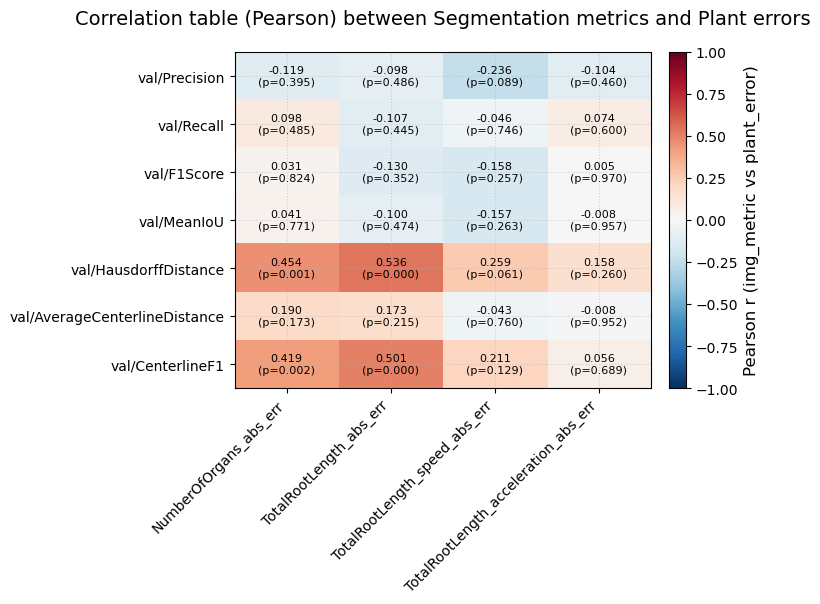

In [36]:
import numpy as np
from scipy.stats import pearsonr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_abs_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].dropna().copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            if img_met in scores_img_metrics:
                valid[img_met] = - valid[img_met]
            rho, p = pearsonr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Pearson):")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_abs_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), img_metrics)
plt.xticks(range(len(plant_abs_err)), plant_abs_err, rotation=45, ha="right")
plt.title("Correlation table (Pearson) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_abs_err)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_pearson.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_pearson.csv")
#Pvalues.to_csv("corr_img_to_plant_error_pearson_pvalues.csv")

In [37]:
print("Corrélation (ρ Pearson):")
print(CorrSpearman.round(3))

Corrélation (ρ Pearson):
                               NumberOfOrgans_abs_err  \
val/Precision                                  -0.119   
val/Recall                                      0.098   
val/F1Score                                     0.031   
val/MeanIoU                                     0.041   
val/HausdorffDistance                           0.454   
val/AverageCenterlineDistance                   0.190   
val/CenterlineF1                                0.419   

                               TotalRootLength_abs_err  \
val/Precision                                   -0.098   
val/Recall                                      -0.107   
val/F1Score                                     -0.130   
val/MeanIoU                                     -0.100   
val/HausdorffDistance                            0.536   
val/AverageCenterlineDistance                    0.173   
val/CenterlineF1                                 0.501   

                               TotalRootLength_speed_

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def phase_scramble(series, n_surrogates=1000):
    """
    Génère des 'surrogates' (substituts) qui préservent l'autocorrélation (spectre de puissance)
    mais détruisent la phase (relation temporelle spécifique).
    """
    series = np.array(series)
    n = len(series)
    
    # FFT
    f_series = np.fft.rfft(series)
    
    # Génération des phases aléatoires pour chaque surrogate
    # On ne touche pas à la composante DC (f=0) ni à Nyquist si n est pair
    random_phases = np.random.uniform(0, 2*np.pi, (n_surrogates, len(f_series)))
    random_phases[:, 0] = 0 # DC component fixée
    if n % 2 == 0:
        random_phases[:, -1] = 0 # Nyquist fixée si pair
        
    # Ajout des phases aléatoires (rotation dans le plan complexe)
    # f_surrogate = amplitude * exp(i * (phase_originale + phase_aleatoire))
    f_surrogates = f_series * np.exp(1j * random_phases)
    
    # Inverse FFT pour revenir au temporel
    surrogates = np.fft.irfft(f_surrogates, n=n, axis=1)
    
    return surrogates

def ebisuzaki_correlation_test(x, y, n_surrogates=1000, metric='pearson'):
    """
    Calcule la p-value corrigée pour l'autocorrélation via Phase Scrambling.
    """
    # Nettoyage des NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean, y_clean = x[mask], y[mask]
    
    if len(x_clean) < 3:
        return np.nan, np.nan

    # 1. Corrélation observée
    if metric == 'pearson':
        r_obs, _ = pearsonr(x_clean, y_clean)
    elif metric == 'spearman':
        r_obs, _ = spearmanr(x_clean, y_clean)
        
    # 2. Génération des surrogates pour X (Phase Scrambling)
    x_surrogates = phase_scramble(x_clean, n_surrogates)
    
    # 3. Calcul des corrélations nulles
    r_null = []
    for x_surr in x_surrogates:
        if metric == 'pearson':
            r, _ = pearsonr(x_surr, y_clean)
        elif metric == 'spearman':
            r, _ = spearmanr(x_surr, y_clean)
        r_null.append(r)
    
    r_null = np.array(r_null)
    
    # 4. Calcul de la p-value (Test bilatéral)
    # Proportion des surrogates qui ont une corrélation absolue plus forte que l'observée
    p_value = np.mean(np.abs(r_null) >= np.abs(r_obs))
    
    return r_obs, p_value

# --- Exemple d'utilisation dans votre boucle ---
# rho, p = ebisuzaki_correlation_test(valid[img_met], valid[plant_err], n_surrogates=2000)

Corrélation (ρ Pearson):


,NumberOfOrgans_rel_err,TotalRootLength_rel_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_rel_err
val/Precision,-0.056,0.084,-0.036,0.555
val/Recall,0.070,-0.132,-0.143,0.108
val/F1Score,0.046,-0.047,-0.125,0.380
val/MeanIoU,0.072,0.005,-0.091,0.381
val/HausdorffDistance,0.605,0.693,0.501,-0.178
val/AverageCenterlineDistance,0.305,0.362,0.178,0.311
val/CenterlineF1,0.579,0.677,0.473,-0.144


p-values:


/tmp/ipykernel_239387/3506520640.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,NumberOfOrgans_rel_err,TotalRootLength_rel_err,TotalRootLength_speed_rel_err,TotalRootLength_acceleration_rel_err
val/Precision,0.790,0.537,0.893,0.028
val/Recall,0.631,0.344,0.307,0.520
val/F1Score,0.799,0.768,0.535,0.177
val/MeanIoU,0.700,0.980,0.667,0.182
val/HausdorffDistance,0.001,0.000,0.003,0.338
val/AverageCenterlineDistance,0.145,0.029,0.414,0.310
val/CenterlineF1,0.002,0.000,0.006,0.479


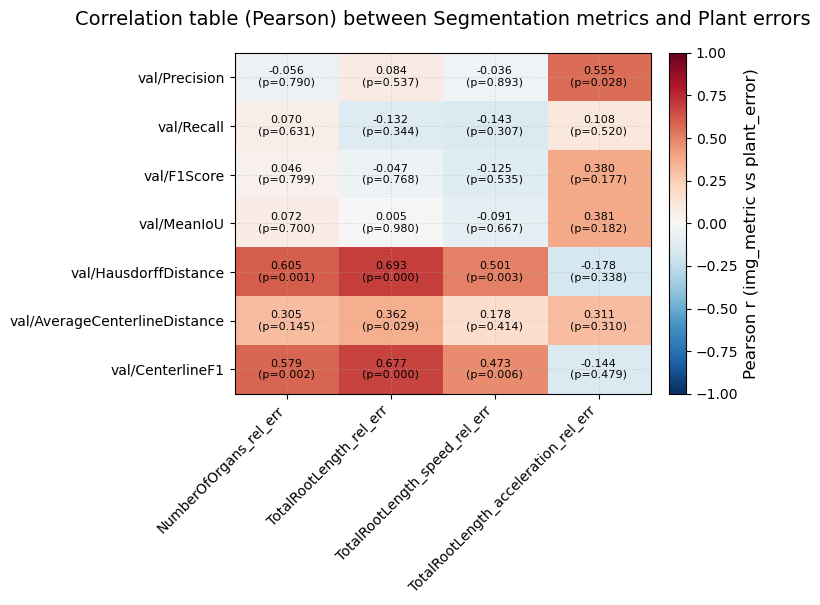

In [32]:
import numpy as np
from scipy.stats import pearsonr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_rel_err:
        # use ebisuzaki_correlation_test instead of pearsonr
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].dropna().copy()
        
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            if img_met in scores_img_metrics:
                valid[img_met] = - valid[img_met]
            rho, p = ebisuzaki_correlation_test(valid[img_met], valid[plant_err], n_surrogates=2000, metric='pearson')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrPearson = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Pearson):")
display(CorrPearson.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_rel_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrPearson.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), img_metrics)
plt.xticks(range(len(plant_rel_err)), plant_rel_err, rotation=45, ha="right")
plt.title("Correlation table (Pearson) between Segmentation metrics and Plant errors", pad=20)

# Annotations: r
for i in range(len(img_metrics)):
    for j in range(len(plant_rel_err)):
        rho = CorrPearson.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_pearson.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrPearson.to_csv("corr_img_to_plant_error_pearson.csv")
#Pvalues.to_csv("corr_img_to_plant_error_pearson_pvalues.csv")

In [33]:
import numpy as np

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_rel_err:
        # use ebisuzaki_correlation_test instead of pearsonr
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].dropna().copy()
        
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            if img_met in scores_img_metrics:
                valid[img_met] = - valid[img_met]
            rho, p = ebisuzaki_correlation_test(valid[img_met], valid[plant_err], n_surrogates=2000, metric='spearman')
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrPearson = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrPearson.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_rel_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrPearson.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman r (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), img_metrics)
plt.xticks(range(len(plant_rel_err)), plant_rel_err, rotation=45, ha="right")
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

# Annotations: r
for i in range(len(img_metrics)):
    for j in range(len(plant_rel_err)):
        rho = CorrPearson.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrPearson.to_csv("corr_img_to_plant_error_pearson.csv")
#Pvalues.to_csv("corr_img_to_plant_error_pearson_pvalues.csv")

KeyboardInterrupt: 

## Per window analysis